In [1]:
import catalogue_analysis as ca
import numpy as np
from astropy.table import join,Table,Column,vstack
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
######################################################################################################################
InputCatalogue="sdata/BGS_Y3_25Feb2026.fits"
RandomCatalogue='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/nonKP/BGS_BRIGHT_7_clustering.ran.fits'
info = True              #choose whether to echo stats on each dataset
plot = True            #set to false if you don't want so many diagnostic plots  
OutputCatalogue = "sdata/BGS2nd_Y3_25Feb2026.fits"  #File into which to save the Augmented Catalogue
######################################################################################################################


# Specify regions to loop over
regions=('S','N')
#
# Read the enhanced BGS catalogue produced by Augment_BGS_cat.ipynb
dat=Table.read(InputCatalogue) 
print('Meta data stored with ths table:')
print(dat.meta)
#
# Check selection cuts agree with stored meta data of the sample we have read
Sel=ca.selection('S')
assert dat.meta['FAINT_S'] == Sel['faint'], f"Faint limits do not match: {dat.meta['FAINT_S']} != {Sel['faint']}"
assert dat.meta['BRIGHT_S'] == Sel['bright'], f"Bright limits do not match: {dat.meta['BRIGHT_S']} != {Sel['bright']}"
assert dat.meta['ZMAX_S'] == Sel['zmax'], f"Zmax do not match: {dat.meta['ZMAX_S']} != {Sel['zmax']}"
assert dat.meta['ZMIN_S'] == Sel['zmin'], f"Zmin do not match: {dat.meta['ZMIN_S']} != {Sel['zmin']}"
assert dat.meta['QEVOL_S'] == Sel['Qevol'], f"Qevol do not match: {dat.meta['QEVOL_S']} != {Sel['Qevol']}"
assert dat.meta['QG_S'] == Sel['Qg'], f"Qg do not match: {dat.meta['QG_S']} != {Sel['Qg']}"
assert dat.meta['QR_S'] == Sel['Qr'], f"Qr do not match: {dat.meta['QR_S']} != {Sel['Qr']}"
assert dat.meta['QZ_S'] == Sel['Qz'], f"Qz do not match: {dat.meta['QZ_S']} != {Sel['Qz']}"
assert dat.meta['QW1_S'] == Sel['Qw1'], f"Qw1 do not match: {dat.meta['QW1_S']} != {Sel['Qw1']}"
assert dat.meta['AREA_S'] == Sel['area'], f"Areas do not match: {dat.meta['AREA_S']} != {Sel['area']}"
assert dat.meta['F_RAN_S'] == Sel['f_ran'], f"f_ran do not match: {dat.meta['F_RAN_S']} != {Sel['f_ran']}"
assert dat.meta['COL_S'] == Sel['col'], f"Colours do not match: {dat.meta['COL_S']} != {Sel['col']}"
assert dat.meta['STYLE_S'] == Sel['style'], f"Styles do not match: {dat.meta['STYLE_S']} != {Sel['style']}"
Sel=ca.selection('N')
assert dat.meta['FAINT_N'] == Sel['faint'], f"Faint limits do not match: {dat.meta['FAINT_N']} != {Sel['faint']}"
assert dat.meta['BRIGHT_N'] == Sel['bright'], f"Bright limits do not match: {dat.meta['BRIGHT_N']} != {Sel['bright']}"
assert dat.meta['ZMAX_N'] == Sel['zmax'], f"Zmax do not match: {dat.meta['ZMAX_N']} != {Sel['zmax']}"
assert dat.meta['ZMIN_N'] == Sel['zmin'], f"Zmin do not match: {dat.meta['ZMIN_N']} != {Sel['zmin']}"
assert dat.meta['QEVOL_N'] == Sel['Qevol'], f"Qevol do not match: {dat.meta['QEVOL_N']} != {Sel['Qevol']}"
assert dat.meta['QG_N'] == Sel['Qg'], f"Qg do not match: {dat.meta['QG_N']} != {Sel['Qg']}"
assert dat.meta['QR_N'] == Sel['Qr'], f"Qr do not match: {dat.meta['QR_N']} != {Sel['Qr']}"
assert dat.meta['QZ_N'] == Sel['Qz'], f"Qz do not match: {dat.meta['QZ_N']} != {Sel['Qz']}"
assert dat.meta['QW1_N'] == Sel['Qw1'], f"Qw1 do not match: {dat.meta['QW1_N']} != {Sel['Qw1']}"
assert dat.meta['AREA_N'] == Sel['area'], f"Areas do not match: {dat.meta['AREA_N']} != {Sel['area']}"
assert dat.meta['F_RAN_N'] == Sel['f_ran'], f"f_ran do not match: {dat.meta['F_RAN_N']} != {Sel['f_ran']}"
assert dat.meta['COL_N'] == Sel['col'], f"Colours do not match: {dat.meta['COL_N']} != {Sel['col']}"
assert dat.meta['STYLE_N'] == Sel['style'], f"Styles do not match: {dat.meta['STYLE_N']} != {Sel['style']}"

# Check cosmology used matches with that used to create the catalogue
assert dat.meta['OM0'] == ca.cosmo.Om0, f"Omega_0 does not match: {dat.meta['OM0']} != {ca.cosmo.Om0}"
assert dat.meta['H0'] == ca.cosmo.H0.value, f"H_0 does not match: {dat.meta['H0']} != {ca.cosmo.H0.value}"
assert dat.meta['TCMB0'] == ca.cosmo.Tcmb0.value, f"Omega_0 does not match: {dat.meta['OM0']} != {ca.cosmo.Tcmb0.value}"
 

if info:
    dat.info('stats')

Meta data stored with ths table:
OrderedDict([('EXTNAME', 'LSS'), ('QEVOL_N', 0.78), ('QG_N', 0.91), ('QR_N', 0.78), ('QZ_N', 0.45), ('QW1_N', 0.7), ('ZMAX_N', 0.6), ('ZMIN_N', 0.002), ('BRIGHT_N', 12.0), ('FAINT_N', 19.54), ('AREA_N', 0.09278121822233744), ('F_RAN_N', 1.0), ('COL_N', 'blue'), ('STYLE_N', 'dashed'), ('QEVOL_S', 0.78), ('QG_S', 0.91), ('QR_S', 0.78), ('QZ_S', 0.45), ('QW1_S', 0.7), ('ZMAX_S', 0.6), ('ZMIN_S', 0.002), ('BRIGHT_S', 12.0), ('FAINT_S', 19.5), ('AREA_S', 0.2067143725378028), ('F_RAN_S', 1.0), ('COL_S', 'red'), ('STYLE_S', 'solid'), ('H0', 100.0), ('TCMB0', 2.725), ('OM0', 0.313), ('PMATCH', False)])
Statistics of the data in the table:
<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.2133

In [3]:
# Read one of the corresponding Y3 random (It is matched to the orginal clustering catalogue and not yet the cuts made to our sample
ranfull=ca.Y3load_catalogues(RandomCatalogue)
ranfull.info('stats')

#Random sample and apply all cuts from the start for a quick run through
Sel=ca.selection('N')# import North selection cuts  
smaskN= (ranfull['Z'] > Sel['zmin']) & (ranfull['Z'] < Sel['zmax']) & (np.random.rand(ranfull['Z'].size)<Sel['f_ran'])\
      & (ranfull['rmag'] < Sel['faint'])  & (ranfull['rmag'] > Sel['bright']) & (ranfull['reg']=='N') 
Sel=ca.selection('S') # import South selection cuts    
smaskS= (ranfull['Z'] > Sel['zmin']) & (ranfull['Z'] < Sel['zmax']) &(np.random.rand(ranfull['Z'].size)<Sel['f_ran']) \
      & (ranfull['rmag'] < Sel['faint'])  & (ranfull['rmag'] > Sel['bright']) & (ranfull['reg']=='S')
smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
ran=ranfull[smask].copy()
del ranfull
print('South sample size:',smaskS.sum())
print('North sample size:',smaskN.sum())

if info:
    ran.info('stats')

<Table length=30890761>
      name           mean        std         min         max    
---------------- ----------- ----------- ----------- -----------
        TARGETID  3.2786e+17 2.48765e+12 3.27858e+17 3.27868e+17
              RA     182.362     93.1026 1.44426e-05         360
             DEC     22.0439     23.2156    -19.5674     79.2522
           NTILE     2.24559    0.944439           1           5
         PHOTSYS          --          --          --          --
FRAC_TLOBS_TILES    0.977861   0.0316573           0           1
               Z    0.213384    0.104274  0.00200098     0.59999
          WEIGHT     1.26497    0.755124           0     68.9124
      WEIGHT_SYS           1           0           1           1
     WEIGHT_COMP     1.29179    0.769686           1          69
    WEIGHT_ZFAIL     1.00127  0.00520768           1     1.19818
   TARGETID_DATA 3.96297e+16 2.48594e+12 3.96273e+16 3.96374e+16
    flux_g_dered     26.5728     94.3445    -72.8934     9805.88
 

In [4]:
# Set up jackknife region limits to equally split up the randoms provided
# and assign unique indices to each region for both data and randoms
njack_S=0
dat['ijack']=-999  # default to mean unassigned
ran['ijack']=-999  # default to mean unassigned
for reg in regions:
    regmask = (dat['reg']==reg)   
    ranregmask = (ran['reg']==reg)  
    print('Processing region ',reg)
    if (reg=='S'):
      # set up the RA and dec boundaries  
      njack_S,limits_S=ca.solve_jackknife_nonsq(ran[ranregmask], ndiv_ra=4, ndiv_dec=5, offset=275)
      # assign randoms to regions
      ca.set_jackknife(ran, ranregmask, limits_S, 0, njack_S)
      # assign data to the same regions
      ca.set_jackknife(dat, regmask, limits_S, 0, njack_S)
    else: 
      # set up the RA and dec boundaries   
      njack_N,limits_N=ca.solve_jackknife_nonsq(ran[ranregmask], ndiv_ra=3, ndiv_dec=3, offset=275)
      # assign randoms to regions
      ca.set_jackknife(ran, ranregmask, limits_N, njack_S, njack_N)
      # assign data to the same regions  
      ca.set_jackknife(dat, regmask, limits_N, njack_S, njack_N)
    

Processing region  S
length of data table: 21321530
The number of objects assigned in each region falls in the range: 1066076  to  1066077
Attempting to assign the remaining unassigned   5  objects by expanding jackknife regions by  0.1  degrees
reassigning 1 an additional objects to jackknife region 4
reassigning 1 an additional objects to jackknife region 9
reassigning 1 an additional objects to jackknife region 14
reassigning 1 an additional objects to jackknife region 16
reassigning 1 an additional objects to jackknife region 19
The number of objects assigned in each region falls in the range: 226908  to  294685
Attempting to assign the remaining unassigned   4  objects by expanding jackknife regions by  0.1  degrees
reassigning 2 an additional objects to jackknife region 4
reassigning 1 an additional objects to jackknife region 5
reassigning 1 an additional objects to jackknife region 10
Processing region  N
length of data table: 9569189
The number of objects assigned in each regi

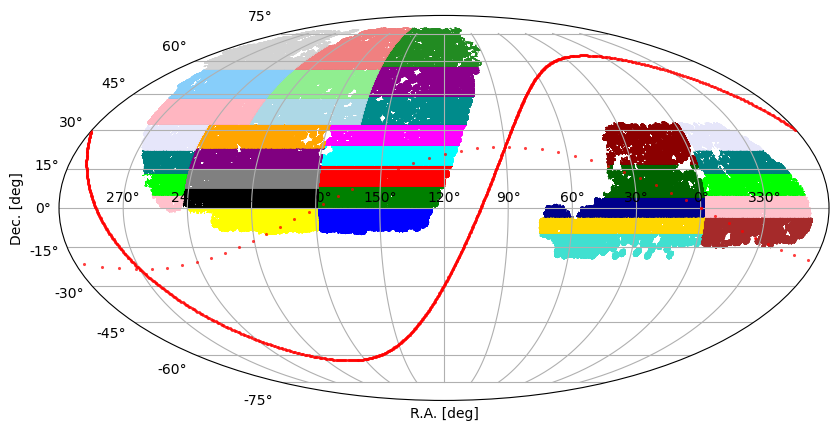

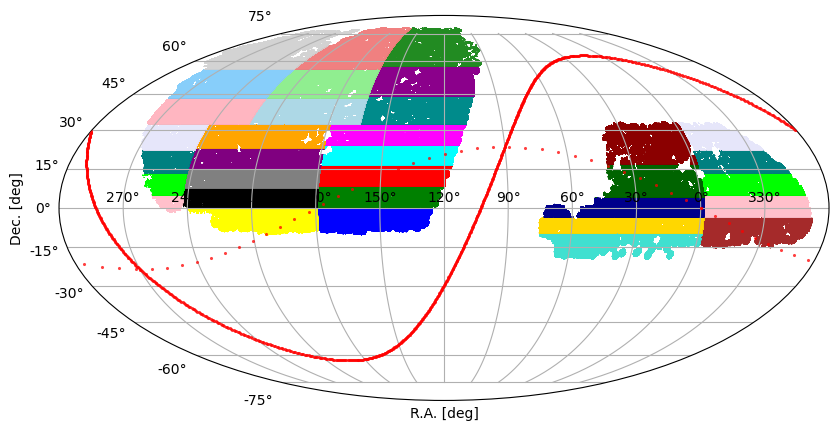

In [5]:
# Visualise the jackknife regions 'Black crosses indicate any unassigned objects'
if plot :
    ca.sky_plot_jack(dat)
    ca.sky_plot_jack(ran)

number of jackknife samples: 9  for region: N  in range: 20 28


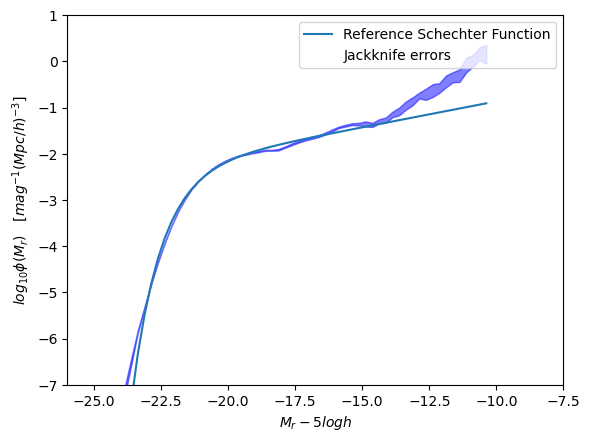

number of jackknife samples: 20  for region: S  in range: 0 19


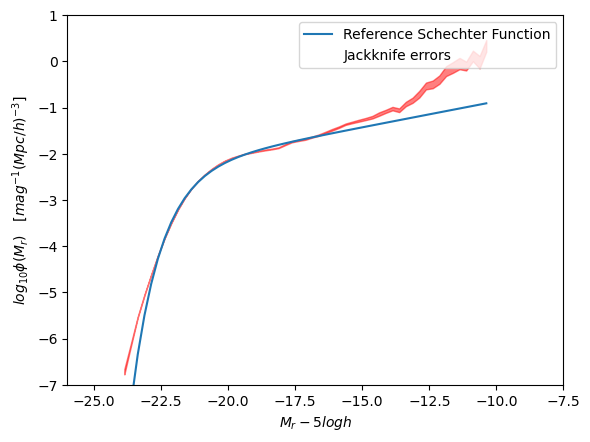

bin width 0.25
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
number in full sample: 2438851
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0013695368084338947
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0013695368084338947
region: N : luminosity density correction factor: 1.0019697588602363
region: N : luminosity density correction factor: 1.0013100839480409
region: N : luminosity density correction factor: 1.0009450764734467
region: N : luminosity density correction factor: 1.0007139065342276
region: N : luminosity density correction factor: 1.0005474722208072
region: N : luminosity density correction factor: 1.0004239349278814
region: N : luminosity density correction factor: 1.0003318455457935
region: N : luminosity density correction factor: 1.0002633253914746
region: N : luminosity density correction factor: 1.000212521986347
region

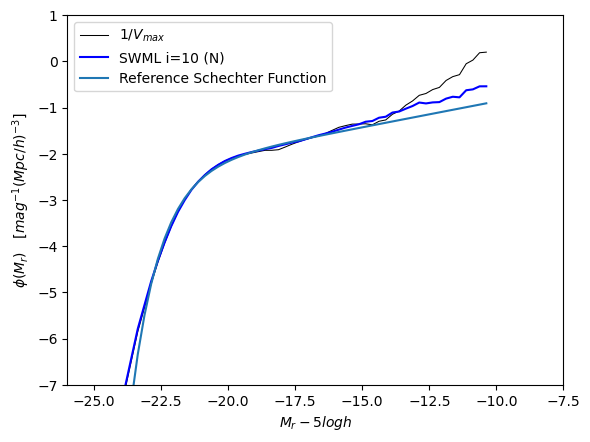

bin width 0.25
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
number in full sample: 5436052
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0017049815021250856
Using cosmological redshift for distance modulus and evolution terms
rms difference between z and zcos= 0.0017049815021250856
region: S : luminosity density correction factor: 1.0044990183519193
region: S : luminosity density correction factor: 1.003271668441038
region: S : luminosity density correction factor: 1.002345602098061
region: S : luminosity density correction factor: 1.0017077708032245
region: S : luminosity density correction factor: 1.001264212236082
region: S : luminosity density correction factor: 1.0009493789544468
region: S : luminosity density correction factor: 1.0007218113691334
region: S : luminosity density correction factor: 1.000555067200814
region: S : luminosity density correction factor: 1.0004317384939998
region: S

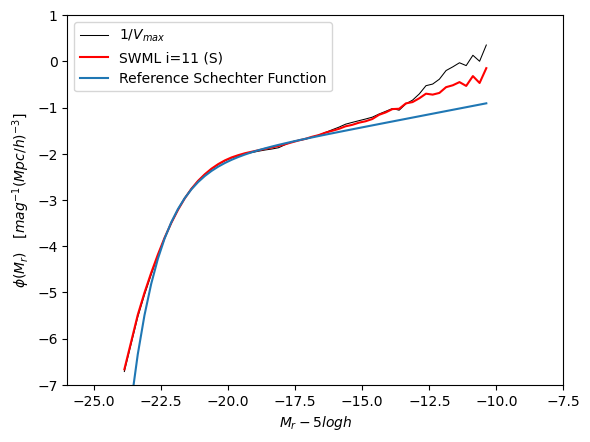

In [6]:
#Compute 1/Vmax LFs then use them to start and normalize SWML LFs and add Vswml to the data table.

#1/Vmax LF estimate
log_phiN_vmax,log_phiN_low,log_phiN_hi,magbins=ca.lumfun_vmax(dat,"N",ratio=False)
log_phiS_vmax,log_phiS_low,log_phiS_hi,magbins=ca.lumfun_vmax(dat,"S",ratio=False)

#SWML LF estimate normalized to that of the initial guess
log_phiNall_swml,magbins=ca.lumfun_swml(dat,'N',log_phiN_vmax,magbins)
#SWML LF estimate normalized to that of the initial guess
log_phiSall_swml,magbins=ca.lumfun_swml(dat,'S',log_phiS_vmax,magbins)

In [20]:
# Following may be very slow and need testing

ca.compute_veff(dat,regions)

starting region  S


NameError: name 'vmax_sample' is not defined

starting region  S


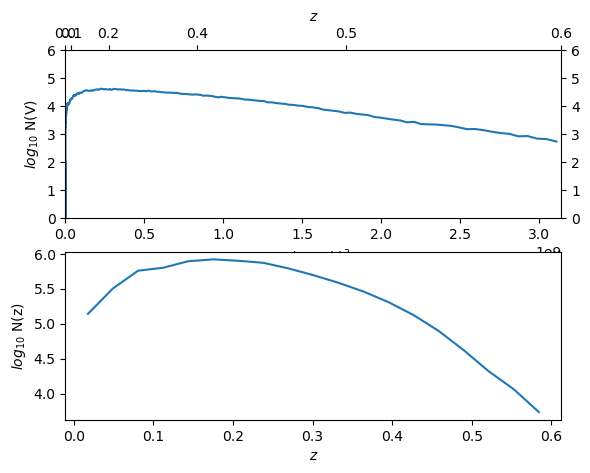

Volume weight Mean Delta_vbin: 0.8405760009876976
Normalized Volume weight Mean Delta_vbin: 1.0000000000000002
RMS Delta: 1.680120544782852
Volume weight Mean Delta_vbin: 1.0598886233053109
Normalized Volume weight Mean Delta_vbin: 1.0000000000000002
RMS Delta: 3.0623119968179053
Volume weight Mean Delta_vbin: 1.0668970496367751
Normalized Volume weight Mean Delta_vbin: 1.0
RMS Delta: 3.733901919424916
Volume weight Mean Delta_vbin: 1.07558884747536
Normalized Volume weight Mean Delta_vbin: 0.9999999999999999
RMS Delta: 5.679357629006017
Volume weight Mean Delta_vbin: 1.084522902223887
Normalized Volume weight Mean Delta_vbin: 1.0000000000000002
RMS Delta: 5.305721754913256
Volume weight Mean Delta_vbin: 1.0962763786229615
Normalized Volume weight Mean Delta_vbin: 1.0
RMS Delta: 6.911405905816422
Volume weight Mean Delta_vbin: 1.1133988620912838
Normalized Volume weight Mean Delta_vbin: 0.9999999999999999
RMS Delta: 7.688129416440461
Volume weight Mean Delta_vbin: 1.1298451992267295
No

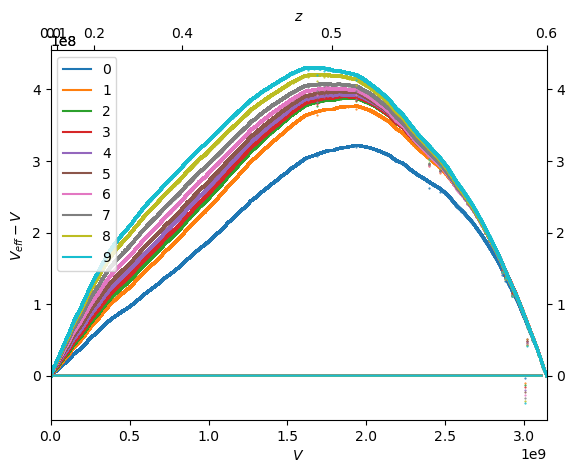

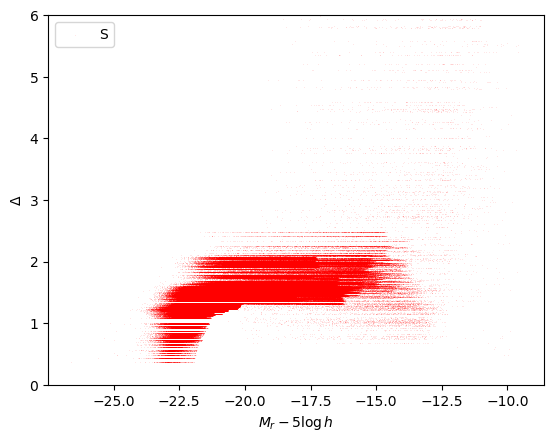

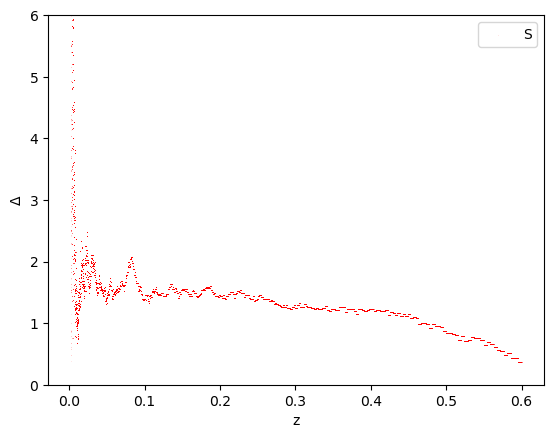

starting region  N


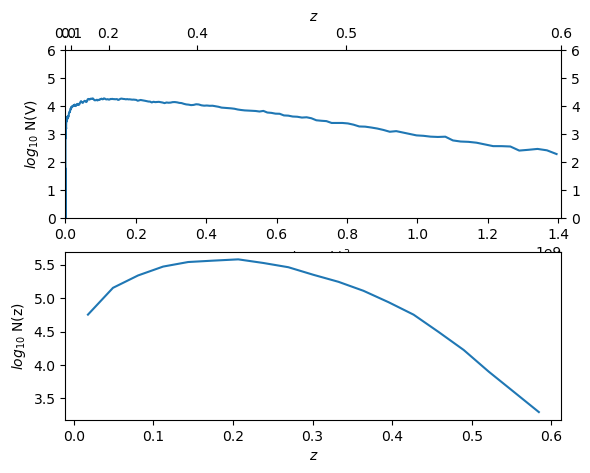

Volume weight Mean Delta_vbin: 0.8926945039243567
Normalized Volume weight Mean Delta_vbin: 0.9999999999999994
RMS Delta: 4.265079341300233
Volume weight Mean Delta_vbin: 1.0825427614149188
Normalized Volume weight Mean Delta_vbin: 1.0000000000000004
RMS Delta: 5.18741041308805
Volume weight Mean Delta_vbin: 1.1038810684713483
Normalized Volume weight Mean Delta_vbin: 1.0000000000000004
RMS Delta: 4.910017741865479
Volume weight Mean Delta_vbin: 1.1073386855581737
Normalized Volume weight Mean Delta_vbin: 0.9999999999999998
RMS Delta: 7.271189573670734
Volume weight Mean Delta_vbin: 1.1090118331073302
Normalized Volume weight Mean Delta_vbin: 0.9999999999999998
RMS Delta: 7.473712581123423
Volume weight Mean Delta_vbin: 1.1097523210712947
Normalized Volume weight Mean Delta_vbin: 1.0000000000000002
RMS Delta: 6.9439823541129435
Volume weight Mean Delta_vbin: 1.1108855498232144
Normalized Volume weight Mean Delta_vbin: 0.9999999999999998
RMS Delta: 8.751090334013094
Volume weight Mean D

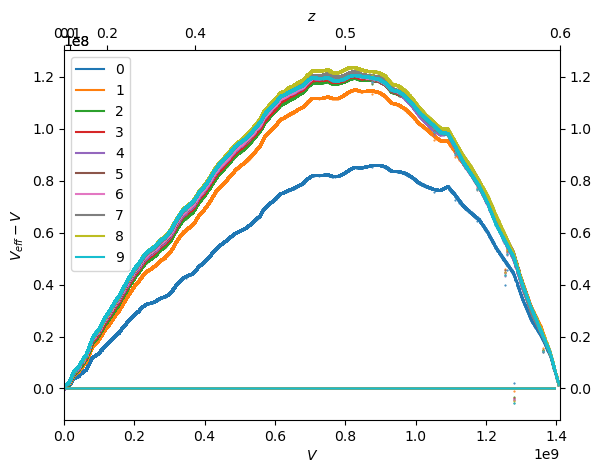

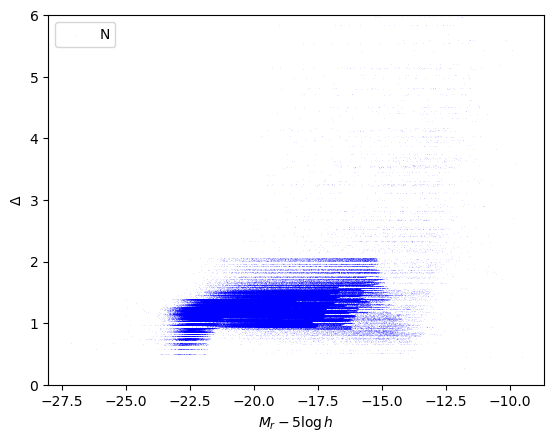

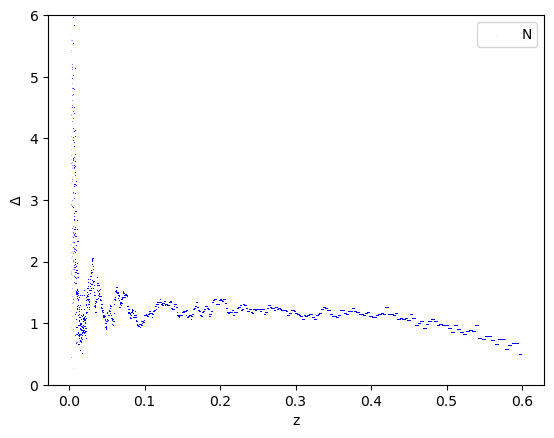

<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213345    0.104259   0.00200098     0.59999
             NTILE      2.43434    0.916934            1           5
                RA      183.078     91.2515  0.000108207         360
               DEC      21.9899     23.0655     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
        BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
          PROB_OBS       0.8551    0.209397            0           1
            WEIGHT      1.30432    0.790294            1     74.1026
       WEIG

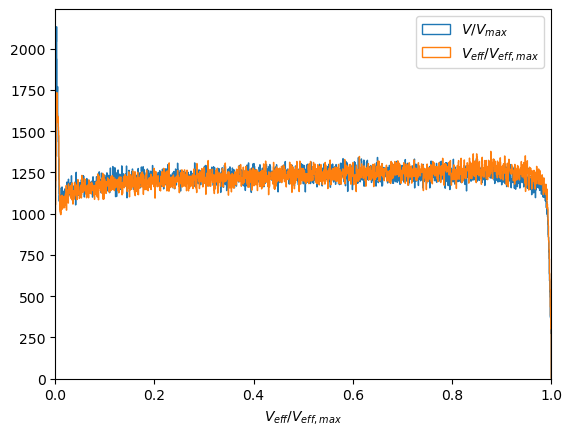

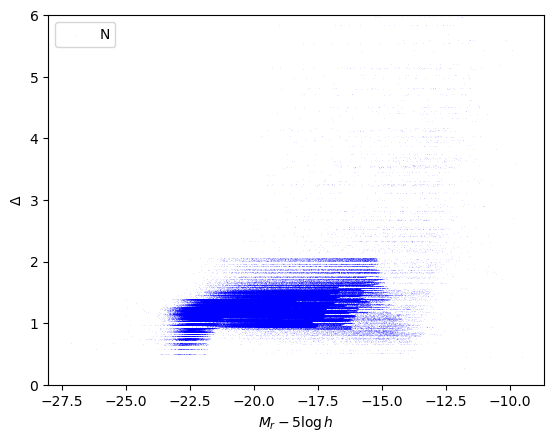

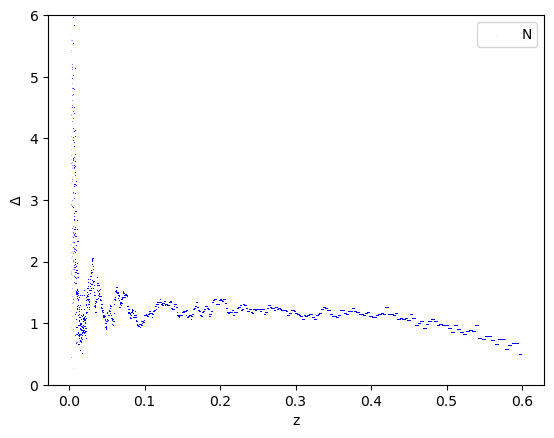

In [7]:
ca.compute_veff_logspacing(dat,regions)

Using Vswml rather than Vmax in LF estimate.
number of jackknife samples: 20  for region: S  in range: 0 19
Using Vswml rather than Vmax in LF estimate.
number of jackknife samples: 9  for region: N  in range: 20 28


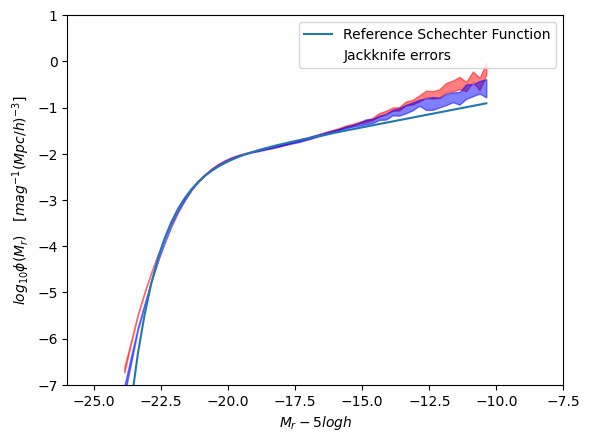

In [18]:
#1/Veff_max LF estimate
log_phi_veffmax,log_phieff_low,log_phieff_hi,magbins=ca.lumfun_vmax(dat,regions,Vchoice="Vswml")

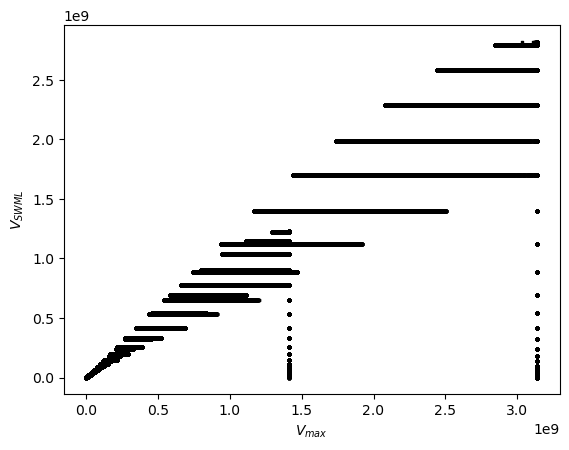

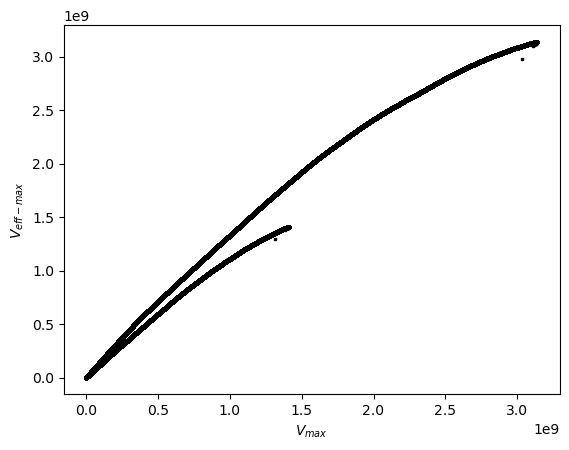

In [17]:
# Compare the different Vmax estimates
plt.scatter(dat['vmax'],dat['vswml'],marker=',',lw=1,s=1,color='black')
plt.xlabel("$V_{max}$")
plt.ylabel("$V_{SWML}$")
plt.show()

plt.scatter(dat['vmax'],dat['veff_max'],marker=',',lw=1,s=1,color='black')
plt.xlabel("$V_{max}$")
plt.ylabel("$V_{eff-max}$")
plt.show()

In [19]:
# Write the table complete with its meta data
#
dat.write(OutputCatalogue,overwrite=True) 
if info:
    # quick look at the stats of the final augmented data set
    dat.info('stats')

<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213345    0.104259   0.00200098     0.59999
             NTILE      2.43434    0.916934            1           5
                RA      183.078     91.2515  0.000108207         360
               DEC      21.9899     23.0655     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
        BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
          PROB_OBS       0.8551    0.209397            0           1
            WEIGHT      1.30432    0.790294            1     74.1026
       WEIG